In [27]:
from rdkit.Chem import AllChem as Chem

import pandas as pd

from chembl_structure_pipeline import standardizer

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from rdkit.Chem import Lipinski
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Descriptors

import seaborn as sns
import numpy as np

from rdkit.Chem import MACCSkeys

In [10]:
suppl = Chem.SDMolSupplier('../data/drugbank.sdf')
drugbank_df = pd.DataFrame({"source": "drugbank", "mol": mol, "id": mol.GetProp("DATABASE_ID")} for mol in suppl if mol)
drugbank_df.set_index("id", inplace=True)
drugbank_df

,source,mol
id,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000014C336...
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000014C336...
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000014C336...
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000014C336...
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000014C336...
...,...,...
DB13154,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000014C333...
DB13155,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000014C333...
DB13156,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000014C333...


In [11]:
zinc_df = pd.read_csv("../data/zinc_random_structures.txt", delimiter=" ")
zinc_df.rename(columns={"zincid": "id"}, inplace=True)
zinc_df.set_index("id", inplace=True)
zinc_df['source'] = 'zinc'
zinc_df['mol'] = zinc_df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))
zinc_df.drop(columns=['tranche', 'SMILES'], inplace=True)
zinc_df

,source,mol
id,,
ZINCtA000001eUS8,zinc,<rdkit.Chem.rdchem.Mol object at 0x0000014C333...
ZINCpo00001BLwat,zinc,<rdkit.Chem.rdchem.Mol object at 0x0000014C333...
ZINCtz000004JjrO,zinc,<rdkit.Chem.rdchem.Mol object at 0x0000014C333...
ZINCsN000009NpXg,zinc,<rdkit.Chem.rdchem.Mol object at 0x0000014C333...
ZINCsN000009NsBY,zinc,<rdkit.Chem.rdchem.Mol object at 0x0000014C333...
...,...,...
ZINCrn00001eRwYj,zinc,<rdkit.Chem.rdchem.Mol object at 0x0000014C453...
ZINCsN000009Nrlo,zinc,<rdkit.Chem.rdchem.Mol object at 0x0000014C453...
ZINCtB00000oxE6f,zinc,<rdkit.Chem.rdchem.Mol object at 0x0000014C453...


In [12]:
mtor_df = pd.read_csv("../data/chembl_mtor_ic50.csv", delimiter=";", usecols=["Molecule ChEMBL ID", "Smiles"])
mtor_df.rename(columns={"Molecule ChEMBL ID": "id"}, inplace=True)
mtor_df.set_index("id", inplace=True)
mtor_df['source'] = 'chembl'
mtor_df['mol'] = mtor_df['Smiles'].apply(lambda x: Chem.MolFromSmiles(x))
mtor_df.drop(columns=['Smiles'], inplace=True)
mtor_df

,source,mol
id,,
CHEMBL1773577,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000014C336...
CHEMBL1773561,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000014C336...
CHEMBL1773077,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000014C336...
CHEMBL1773580,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000014C336...
CHEMBL1773578,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000014C336...
...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000014C453...
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000014C453...
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000014C453...


In [13]:
structures = pd.concat([drugbank_df, zinc_df, mtor_df])

In [14]:
fp =MACCSkeys.GenMACCSKeys(Chem.MolFromSmiles("CCCC"))

In [15]:
structures["MACCS"] = structures["mol"].apply(MACCSkeys.GenMACCSKeys)

In [34]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=3)

In [35]:
structures["ECFP6"] = structures["mol"].apply(morgan_gen.GetSparseCountFingerprint)

In [16]:
sources = ["chembl", "drugbank", "zinc"]

In [17]:
maccs=[]
for source in sources:
    maccs.append(pd.DataFrame(zip(*structures[structures["source"]==source]["MACCS"])))

In [18]:
for s, m in zip(sources,maccs):
    r = [(i,s) for i,s in enumerate(list(m.sum(axis=1)))]
    r.sort(key=lambda x: x[1], reverse=True)
    print(s, r[:10])

chembl [(165, 4596), (137, 4595), (163, 4595), (161, 4591), (145, 4569), (121, 4566), (120, 4565), (156, 4557), (158, 4545), (162, 4541)]
drugbank [(164, 6512), (165, 6137), (163, 5802), (161, 5687), (159, 5682), (158, 5357), (156, 5261), (157, 5260), (162, 5179), (155, 4858)]
zinc [(161, 7153), (165, 7150), (156, 7139), (158, 7136), (164, 7092), (142, 6980), (153, 6842), (154, 6773), (117, 6716), (110, 6668)]


In [19]:
r.sort(key=lambda x: x[1], reverse=True)

In [21]:
maccs

[     0     1     2     3     4     5     6     7     8     9     ...  4586  \
 0       0     0     0     0     0     0     0     0     0     0  ...     0   
 1       0     0     0     0     0     0     0     0     0     0  ...     0   
 2       0     0     0     0     0     0     0     0     0     0  ...     0   
 3       0     0     0     0     0     0     0     0     0     0  ...     0   
 4       0     0     0     0     0     0     0     0     0     0  ...     0   
 ..    ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   ...   
 162     1     1     1     1     1     1     1     1     1     1  ...     1   
 163     1     1     1     1     1     1     1     1     1     1  ...     1   
 164     1     1     1     1     1     1     1     1     1     1  ...     1   
 165     1     1     1     1     1     1     1     1     1     1  ...     1   
 166     0     0     0     0     0     0     0     0     0     0  ...     0   
 
      4587  4588  4589  4590  4591  4592  4593  45

In [22]:
from rdkit.Chem import rdFingerprintGenerator

In [23]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=6)
rdkit_gen = rdFingerprintGenerator.GetRDKitFPGenerator()

In [24]:
mol = Chem.MolFromSmiles("CCCCCO")

In [25]:
list(morgan_gen.GetFingerprint(mol).GetOnBits()),list(rdkit_gen.GetFingerprint(mol).GetOnBits())

([80, 222, 294, 473, 541, 591, 794, 807, 1057, 1130, 1324, 1444, 1911],
 [148,
  198,
  562,
  568,
  709,
  875,
  1118,
  1183,
  1233,
  1246,
  1308,
  1339,
  1728,
  1772,
  1813,
  1817,
  1927,
  1968])

In [ ]:
cbv=morgan_gen.GetCountFingerprint(mol)

In [ ]:
cbv.GetNonzeroElements()

In [ ]:
fp = mfpgen.GetFingerprint(ms[0])
sfp = mfpgen.GetSparseFingerprint(ms[0])

# count vectors:
cfp = mfpgen.GetCountFingerprint(ms[0])
scfp = morgan_gen.GetSparseCountFingerprint(ms[0])

In [6]:
benzen = Chem.MolFromSmiles("c1ccccc1")

In [20]:
list(morgan_gen.GetFingerprint(benzen).GetOnBits())

[389, 1088, 1232, 1873]

In [7]:
scfp = morgan_gen.GetSparseCountFingerprint(benzen)

In [9]:
scfp.GetNonzeroElements()

{98513984: 6, 2763854213: 6, 3218693969: 6, 3741631696: 1}

In [29]:
m = Chem.MolFromSmiles('c1cccnc1C')
fpgen = Chem.GetMorganGenerator(radius=2)
ao = Chem.AdditionalOutput()
ao.CollectBitInfoMap()
fp = fpgen.GetSparseCountFingerprint(m,additionalOutput=ao)

In [30]:
fp.GetNonzeroElements()

{98513984: 2,
 422715066: 1,
 951226070: 1,
 1100037548: 1,
 1207774339: 1,
 1235524787: 1,
 1751362425: 1,
 2041434490: 1,
 2246728737: 1,
 2614860224: 1,
 3217380708: 1,
 3218693969: 4,
 3776905034: 1,
 3999906991: 1,
 4036277955: 1,
 4048591891: 1}

In [31]:
info = ao.GetBitInfoMap()

In [32]:
info

{98513984: ((1, 1), (2, 1)),
 422715066: ((6, 1),),
 951226070: ((0, 1),),
 1100037548: ((4, 1),),
 1207774339: ((2, 2),),
 1235524787: ((0, 2),),
 1751362425: ((4, 2),),
 2041434490: ((4, 0),),
 2246728737: ((6, 0),),
 2614860224: ((3, 2),),
 3217380708: ((5, 0),),
 3218693969: ((0, 0), (1, 0), (2, 0), (3, 0)),
 3776905034: ((3, 1),),
 3999906991: ((1, 2),),
 4036277955: ((5, 1),),
 4048591891: ((5, 2),)}

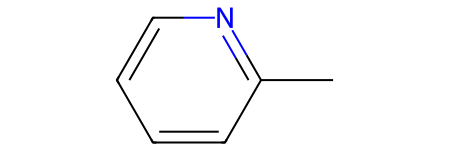

In [33]:
m

In [48]:
from collections import defaultdict

In [69]:
data = defaultdict(lambda: defaultdict(list))

for index, row in structures.iterrows():
    for fr_id in row["ECFP6"].GetNonzeroElements():
        data[row["source"]][fr_id].append(index)
    # index, row["ECFP6"], row["source"] 

defaultdict(list,
            {150310: ['CHEMBL1773577',
              'CHEMBL1773561',
              'CHEMBL1773077',
              'CHEMBL1773580',
              'CHEMBL1773578',
              'CHEMBL1946264',
              'CHEMBL1946266',
              'CHEMBL1773585',
              'CHEMBL1773574',
              'CHEMBL1773579',
              'CHEMBL1773595',
              'CHEMBL1773560',
              'CHEMBL1773570',
              'CHEMBL1946261',
              'CHEMBL1946265',
              'CHEMBL1946266',
              'CHEMBL1773571',
              'CHEMBL1773573',
              'CHEMBL1946262',
              'CHEMBL1946265',
              'CHEMBL1946262',
              'CHEMBL2158855',
              'CHEMBL2158854',
              'CHEMBL2158866',
              'CHEMBL1946266',
              'CHEMBL1946263',
              'CHEMBL1946267',
              'CHEMBL1773597',
              'CHEMBL3693506',
              'CHEMBL3693511',
              'CHEMBL3693520',
             

In [74]:
ress = [(s, sorted(d.items(), key=lambda x: len(x[1]), reverse=True)[:10]) for s, d in data.items()]

In [59]:
inter = list(x for x,y in res[:10])

In [58]:
len(res), len(structures)

(178194, 18896)

In [67]:
for i_frag in inter:
    m = structures.loc[data[i_frag][0]]["mol"]
    ao = Chem.AdditionalOutput()
    ao.CollectBitInfoMap()
    fp = morgan_gen.GetSparseCountFingerprint(m,additionalOutput=ao)
    info = ao.GetBitInfoMap()
    print(i_frag, info[i_frag])

3217380708 ((21, 0), (75, 0), (137, 0), (140, 0))
3218693969 ((22, 0), (23, 0), (24, 0), (25, 0), (26, 0), (76, 0), (77, 0), (78, 0), (79, 0), (80, 0), (138, 0), (139, 0), (142, 0), (143, 0))
864942730 ((10, 0), (17, 0), (28, 0), (35, 0), (39, 0), (43, 0), (47, 0), (51, 0), (57, 0), (59, 0), (63, 0), (69, 0), (71, 0), (82, 0), (89, 0), (91, 0), (98, 0), (100, 0), (108, 0), (115, 0), (122, 0), (124, 0), (131, 0), (133, 0), (145, 0), (154, 0))
2246728737 ((104, 0), (106, 0), (150, 0), (151, 0))
2245384272 ((4, 0), (5, 0), (6, 0), (20, 0), (37, 0), (41, 0), (45, 0), (49, 0), (54, 0), (61, 0), (66, 0), (74, 0), (85, 0), (86, 0), (94, 0), (95, 0), (105, 0), (118, 0), (119, 0), (127, 0), (128, 0), (136, 0), (148, 0))
2246699815 ((1, 0), (9, 0), (16, 0), (27, 0), (34, 0), (38, 0), (42, 0), (46, 0), (50, 0), (55, 0), (58, 0), (62, 0), (67, 0), (70, 0), (81, 0), (87, 0), (90, 0), (96, 0), (99, 0), (107, 0), (114, 0), (120, 0), (123, 0), (129, 0), (132, 0), (144, 0), (152, 0))
2968968094 ((12, 0

In [65]:
structures.loc[data[i_frag][0]]

source                                             drugbank
mol       <rdkit.Chem.rdchem.Mol object at 0x0000014C336...
MACCS     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
ECFP6     <rdkit.DataStructs.cDataStructs.ULongSparseInt...
Name: DB00006, dtype: object

In [77]:
[(s, *(x[0] for x in d))for s,d in ress]

[('drugbank',
  3217380708,
  864942730,
  3218693969,
  2245384272,
  864662311,
  951226070,
  2246728737,
  2246699815,
  1510328189,
  2976033787),
 ('zinc',
  864942730,
  2246699815,
  1510328189,
  2246728737,
  2968968094,
  2245384272,
  3217380708,
  3218693969,
  847961216,
  2976033787),
 ('chembl',
  3217380708,
  3218693969,
  2041434490,
  951226070,
  2092489639,
  2246728737,
  2968968094,
  2353112200,
  864942730,
  1101907775)]

In [79]:
dexamethasone = Chem.MolFromSmiles("O=C(CO)[C@]3(O)[C@]2(C[C@H](O)[C@]4(F)[C@@]1(C(=CC(=O)C=C1)CC[C@H]4[C@@H]2C[C@H]3C)C)C")

In [81]:
from rdkit import DataStructs

In [85]:
similarity = []
dexa_fp = morgan_gen.GetSparseCountFingerprint(dexamethasone)
for index, row in structures.iterrows():
    similarity.append((index, DataStructs.TanimotoSimilarity(row["ECFP6"], dexa_fp)))
        

In [92]:
similarity.sort(key=lambda x: x[1], reverse=True)

In [94]:
similarity[:10]

[('DB00443', 1.0),
 ('DB01234', 1.0),
 ('DB00620', 0.7714285714285715),
 ('DB08970', 0.6460176991150443),
 ('DB00223', 0.6347826086956522),
 ('DB00663', 0.6347826086956522),
 ('DB01013', 0.6048387096774194),
 ('DB00764', 0.603448275862069),
 ('DB00547', 0.6),
 ('DB00596', 0.5409836065573771)]

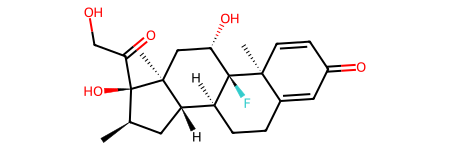

In [80]:
dexamethasone

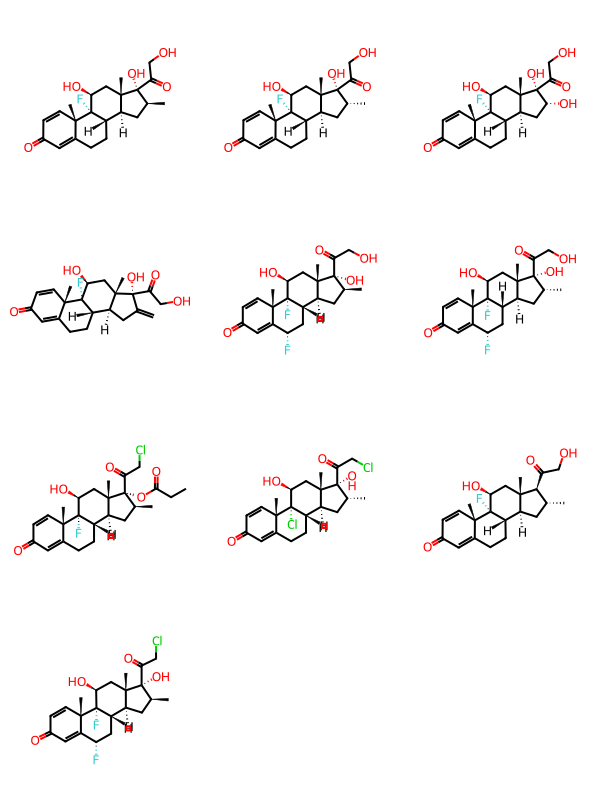

In [103]:
Draw.MolsToGridImage(list(structures.loc[idx]["mol"] for idx, s in similarity[:10]))

In [98]:
from rdkit.Chem import Draw